# Ejercicio 2: Similitud entre series con `catch22`

Se aborda el ejercicio 2 del laboratorio, donde cada bloque de este cuaderno está etiquetado con el número de inciso al que corresponde.

**Resumen**

| Inciso | Contenido | Sección |
|---|---|---|
| 2 | Series utilizadas | 2 |
| 2.1 | Idea detrás de catch22 | 2.1 |
| 2.2 | Extracción de las 22 características | 2.2 |
| 2.3 | Matriz series × características | 2.3 |
| 2.4 | Estandarización | 2.4 |
| 2.5 | PCA, clustering, heatmap, correlación, distancias | 2.5.1 – 2.5.5 |
| 2.6 – 2.13 | Análisis e interpretación | 2.6 – 2.13 |
| 2.14 | LSTM con características catch22 vs. mejor LSTM previo | 2.14 |




## 0. Configuración e importación de librerías

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

import pycatch22 as catch22
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

AZUL, NARANJA, VERDE, ROJO, GRIS, MORADO = "#2563eb", "#f59e0b", "#10b981", "#ef4444", "#94a3b8", "#8b5cf6"
PALETA = [AZUL, NARANJA, VERDE, ROJO, MORADO, "#14b8a6", "#ec4899", GRIS, "#f97316"]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

DIR_PROC = Path("./data")


## 2. Series utilizadas

Se utilizan todas las series construidas en el laboratorio anterior: la serie
`Total`, las 4 series de la categoría *Tipo de viajero* + la combinada
(`Turista`, `Excursionista`, `Cruceristas`, `Viajero`, `Turista + Excursionista`), y las 3
series de la categoría *País de residencia* (Top-3): `País: Guatemala`,
`País: El Salvador`, `País: Estados Unidos de América`. En total, **9 series**, cada una
con sus 147 observaciones mensuales de entrenamiento (enero 2009 – marzo 2021).

In [2]:
train = pd.read_csv(DIR_PROC / "series_mensuales_train.csv", index_col=0, parse_dates=True)
train.index.freq = pd.tseries.frequencies.to_offset("MS")

print(f"{train.shape[1]} series, {train.shape[0]} meses cada una ({train.index.min().date()} a {train.index.max().date()})")
for c in train.columns:
    print(f"  - {c}")


9 series, 147 meses cada una (2009-01-01 a 2021-03-01)
  - Total
  - Cruceristas
  - Excursionista
  - Turista
  - Viajero
  - Turista + Excursionista
  - País: Guatemala
  - País: El Salvador
  - País: Estados Unidos de América


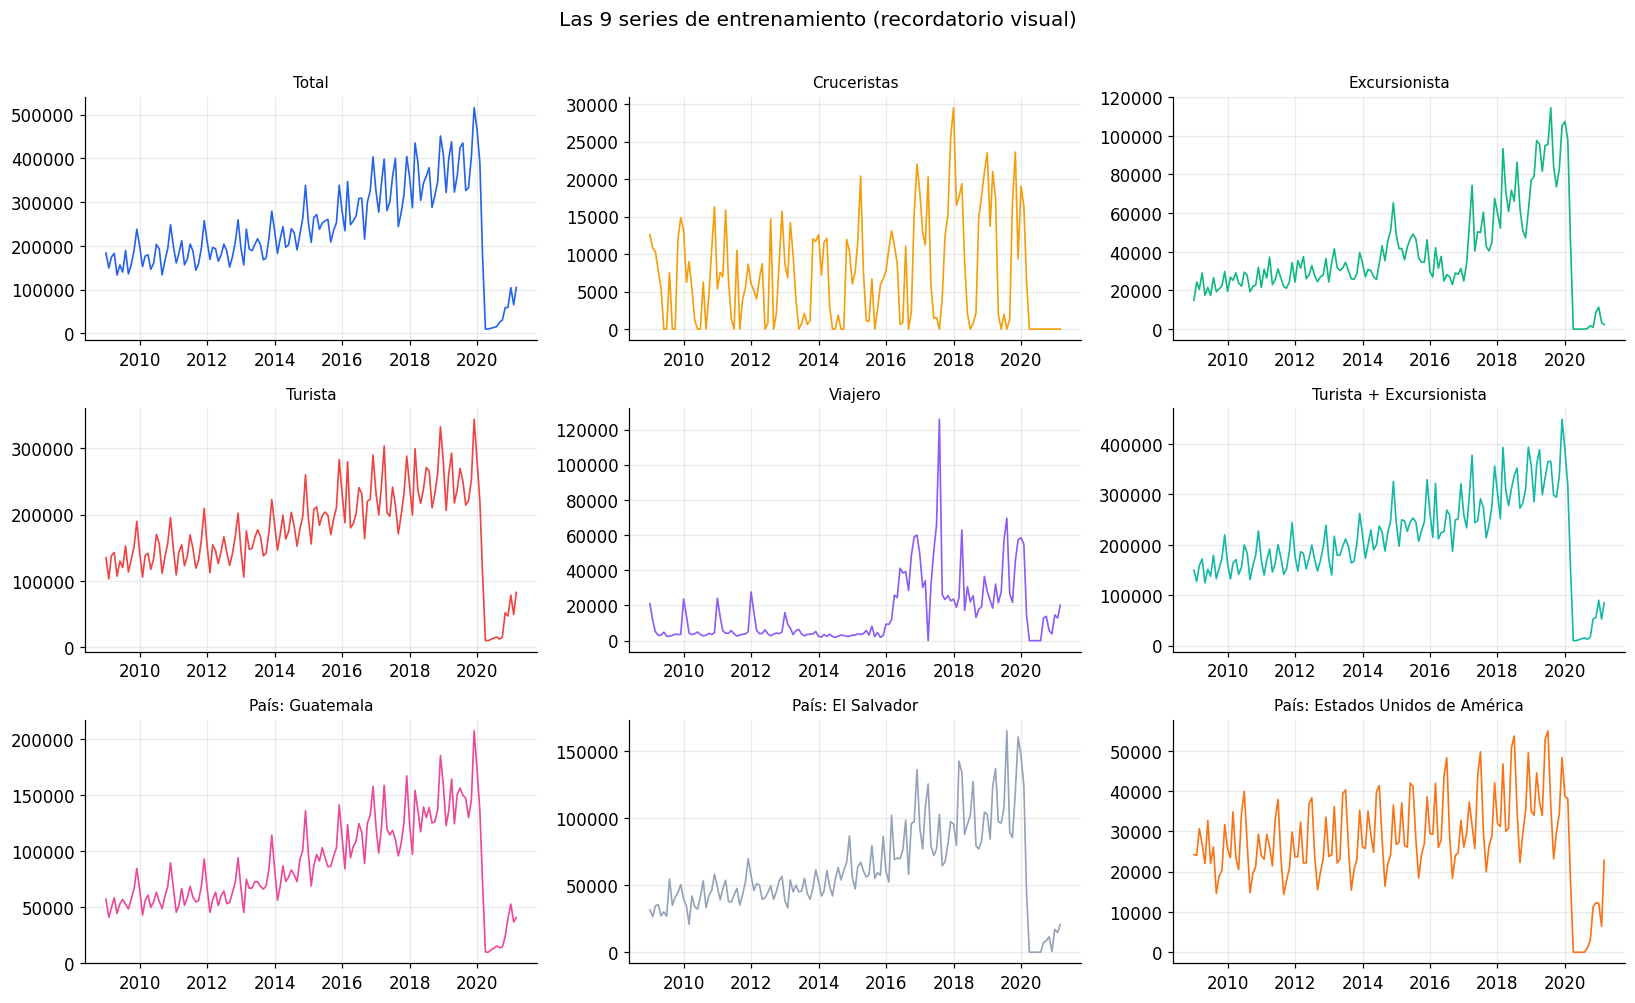

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=False)
for ax, (col, color) in zip(axes.flatten(), zip(train.columns, PALETA)):
    ax.plot(train.index, train[col].values, color=color, linewidth=1.1)
    ax.set_title(col, fontsize=10)
fig.suptitle("Las 9 series de entrenamiento (recordatorio visual)", y=1.01)
plt.tight_layout(); plt.show()


## 2.1. ¿Cuál es la idea detrás de catch22 y por qué es importante?

`catch22` o *22 CAnonical Time-series CHaracteristics* es un conjunto reducido de 22
características seleccionadas, mediante un proceso basado en datos, a partir de un
banco mucho más grande de series de tiempo (la librería
*hctsa*, *highly comparative time-series analysis*). La idea central, presentada por Lubba
et al. (2019), es la siguiente:

- Se evaluó el poder de más de 7,000 características para distinguir y/o clasificar series
  de tiempo en decenas de conjuntos de datos reales muy diversos.
- Mediante un procedimiento de selección,
  se redujo ese banco a solo 22 características que, en conjunto, conservan casi todo el
  poder discriminativo del conjunto completo de 7,000+.
- Cada una de las 22 características resultantes es, además, interpretable, es decir que mide algo
  concreto, como la forma de la distribución, memoria,autocorrelación, periodicidad, predictibilidad, etc. y barata de calcular.

**¿Por qué es importante?** Porque permite resumir cualquier serie de tiempo sin
importar su longitud o escala en un vector numérico fijo de 22 valores que puede
compararse directamente con el de otra serie usando distancias, clustering o PCA, algo que
comparar las series "punto a punto" no permite.

## 2.2. Extracción de las 22 características de catch22

Se calcula el conjunto completo de 22 características de `catch22` para cada una de
las 9 series de entrenamiento.

In [4]:
filas_features = {}
nombres_features = None
for col in train.columns:
    valores = train[col].dropna().astype(float).values.tolist()
    resultado = catch22.catch22_all(valores)
    filas_features[col] = resultado["values"]
    nombres_features = resultado["names"]

print(f"Se calcularon {len(nombres_features)} características para cada una de las {len(filas_features)} series.")
print("\nNombres de las 22 características de catch22:")
for n in nombres_features:
    print(" -", n)


Se calcularon 22 características para cada una de las 9 series.

Nombres de las 22 características de catch22:
 - DN_HistogramMode_5
 - DN_HistogramMode_10
 - CO_f1ecac
 - CO_FirstMin_ac
 - CO_HistogramAMI_even_2_5
 - CO_trev_1_num
 - MD_hrv_classic_pnn40
 - SB_BinaryStats_mean_longstretch1
 - SB_TransitionMatrix_3ac_sumdiagcov
 - PD_PeriodicityWang_th0_01
 - CO_Embed2_Dist_tau_d_expfit_meandiff
 - IN_AutoMutualInfoStats_40_gaussian_fmmi
 - FC_LocalSimple_mean1_tauresrat
 - DN_OutlierInclude_p_001_mdrmd
 - DN_OutlierInclude_n_001_mdrmd
 - SP_Summaries_welch_rect_area_5_1
 - SB_BinaryStats_diff_longstretch0
 - SB_MotifThree_quantile_hh
 - SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1
 - SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
 - SP_Summaries_welch_rect_centroid
 - FC_LocalSimple_mean3_stderr


## 2.3. Matriz series × características

In [5]:
df_features = pd.DataFrame(filas_features, index=nombres_features).T
df_features.index.name = "Serie"

print(f"Matriz de características: {df_features.shape[0]} filas (series) x {df_features.shape[1]} columnas (características de catch22)")
df_features.round(3)


Matriz de características: 9 filas (series) x 22 columnas (características de catch22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,-0.741,-0.493,8.322,10.0,0.457,-0.108,0.932,42.0,0.062,11.0,...,0.033,0.619,0.891,0.823,6.0,1.780,0.850,0.775,0.147,0.616
Cruceristas,-0.627,-0.840,1.727,6.0,0.111,-0.082,0.870,9.0,0.004,11.0,...,0.250,0.483,0.082,0.680,5.0,2.043,0.175,0.775,0.540,0.983
Excursionista,-0.174,-0.412,7.710,14.0,0.467,-0.100,0.890,38.0,0.023,43.0,...,0.071,0.707,0.884,0.848,4.0,1.870,0.825,0.850,0.147,0.574
Turista,0.019,-0.231,8.163,10.0,0.331,-0.056,0.966,30.0,0.046,11.0,...,0.045,0.524,0.891,0.795,6.0,1.881,0.150,0.775,0.147,0.647
Viajero,-0.159,-0.491,8.768,4.0,0.157,-0.885,0.753,18.0,0.062,4.0,...,0.029,0.422,-0.293,0.653,5.0,1.836,0.850,0.700,0.196,0.809
Turista + Excursionista,0.175,-0.581,8.106,10.0,0.467,-0.068,0.918,30.0,0.046,11.0,...,0.045,0.626,0.891,0.817,6.0,1.833,0.850,0.750,0.147,0.614
País: Guatemala,-0.449,-0.696,8.935,10.0,0.393,-0.019,0.938,49.0,0.111,11.0,...,0.026,0.633,0.857,0.837,6.0,1.722,0.850,0.775,0.098,0.594
País: El Salvador,-0.354,-0.599,8.383,3.0,0.456,-0.129,0.911,42.0,0.062,3.0,...,0.033,0.633,0.884,0.790,5.0,1.770,0.850,0.825,0.147,0.655
País: Estados Unidos de América,-0.042,-0.290,1.767,2.0,0.178,-0.079,0.918,12.0,0.026,3.0,...,0.100,0.469,0.884,0.581,5.0,2.123,0.150,0.700,0.368,0.928


## 2.4. Estandarización de las características

Las 22 características de `catch22` tienen escalas muy distintas entre sí. Antes de cualquier análisis comparativo (PCA, clustering,
distancias) se estandarizan con z-score (media 0, desviación estándar 1) por
característica, para que ninguna domine por su escala.

In [6]:
escalador = StandardScaler()
X = escalador.fit_transform(df_features.values)
X_df = pd.DataFrame(X, index=df_features.index, columns=df_features.columns)

print("Verificación: media y desviación estándar por característica tras estandarizar (deben ser ~0 y ~1):")
print(pd.DataFrame({"media": X_df.mean().round(6), "std": X_df.std(ddof=0).round(6)}).T)


Verificación: media y desviación estándar por característica tras estandarizar (deben ser ~0 y ~1):
       DN_HistogramMode_5  DN_HistogramMode_10  CO_f1ecac  CO_FirstMin_ac  \
media                -0.0                 -0.0       -0.0            -0.0   
std                   1.0                  1.0        1.0             1.0   

       CO_HistogramAMI_even_2_5  CO_trev_1_num  MD_hrv_classic_pnn40  \
media                      -0.0           -0.0                   0.0   
std                         1.0            1.0                   1.0   

       SB_BinaryStats_mean_longstretch1  SB_TransitionMatrix_3ac_sumdiagcov  \
media                               0.0                                 0.0   
std                                 1.0                                 1.0   

       PD_PeriodicityWang_th0_01  ...  FC_LocalSimple_mean1_tauresrat  \
media                        0.0  ...                             0.0   
std                          1.0  ...                             1

## 2.5. Análisis sobre la matriz estandarizada

### 2.5.1. Análisis de Componentes Principales (PCA)

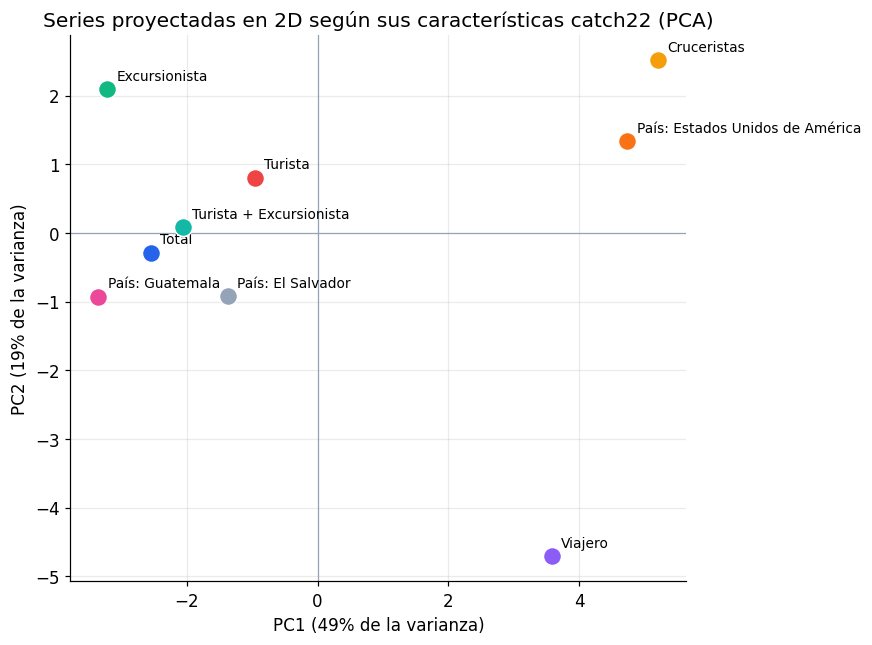

Varianza explicada: PC1=49.3%  PC2=18.8%  Total=68.1%


In [7]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
var_explicada = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
for i, nombre in enumerate(df_features.index):
    ax.scatter(coords[i, 0], coords[i, 1], s=140, color=PALETA[i % len(PALETA)], edgecolor="white", zorder=3)
    ax.annotate(nombre, (coords[i, 0], coords[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.axhline(0, color=GRIS, linewidth=0.8); ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel(f"PC1 ({var_explicada[0]*100:.0f}% de la varianza)")
ax.set_ylabel(f"PC2 ({var_explicada[1]*100:.0f}% de la varianza)")
ax.set_title("Series proyectadas en 2D según sus características catch22 (PCA)")
plt.tight_layout(); plt.show()

print(f"Varianza explicada: PC1={var_explicada[0]*100:.1f}%  PC2={var_explicada[1]*100:.1f}%  Total={sum(var_explicada)*100:.1f}%")


In [8]:
cargas = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=["PC1", "PC2"])
print("Características con mayor peso (carga) en PC1:")
print(cargas.reindex(cargas["PC1"].abs().sort_values(ascending=False).index).head(6))
print("\\nCaracterísticas con mayor peso (carga) en PC2:")
print(cargas.reindex(cargas["PC2"].abs().sort_values(ascending=False).index).head(6))


Características con mayor peso (carga) en PC1:
                                       PC1       PC2
FC_LocalSimple_mean3_stderr       0.297769  0.065277
SP_Summaries_welch_rect_area_5_1 -0.289217  0.048286
CO_HistogramAMI_even_2_5         -0.287988  0.028847
SB_BinaryStats_mean_longstretch1 -0.285466 -0.071720
DN_OutlierInclude_p_001_mdrmd    -0.270416  0.139704
SP_Summaries_welch_rect_centroid  0.258843  0.217724
\nCaracterísticas con mayor peso (carga) en PC2:
                                                  PC1       PC2
CO_trev_1_num                               -0.118090  0.397777
SB_TransitionMatrix_3ac_sumdiagcov          -0.163978 -0.312375
FC_LocalSimple_mean1_tauresrat               0.197072  0.300223
MD_hrv_classic_pnn40                        -0.157864  0.288144
CO_f1ecac                                   -0.235019 -0.287723
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1 -0.192011 -0.270069


### 2.5.2 Clustering

Se aplican dos técnicas complementarias de clustering sobre la matriz estandarizada:
agrupamiento jerárquico (dendrograma) y K-Means (con selección de *k* mediante silhouette
score), para verificar que ambas coincidan en los mismos grupos.

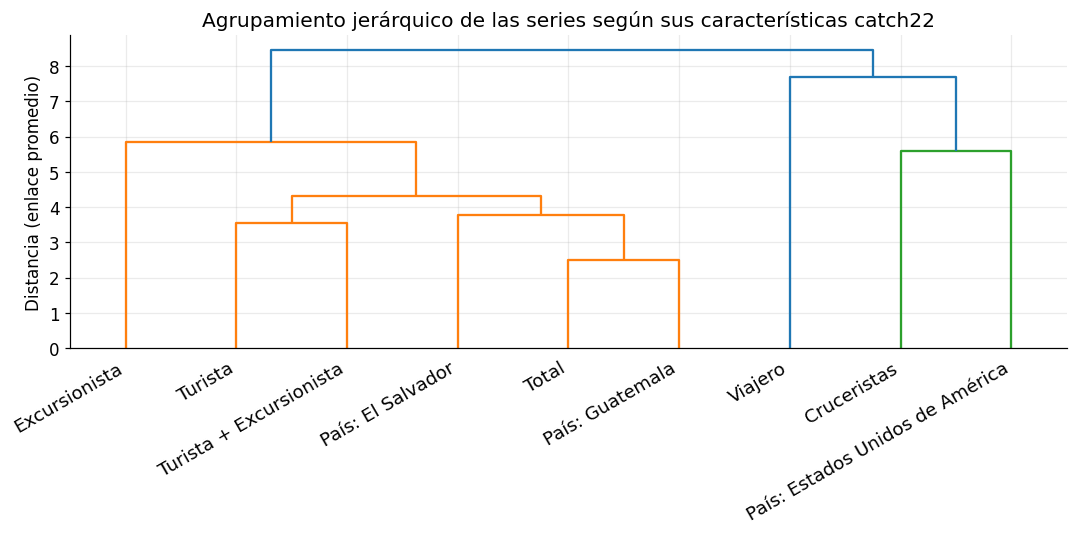

Clusters jerárquicos (corte en 2 grupos):
  Total: grupo 1
  Cruceristas: grupo 2
  Excursionista: grupo 1
  Turista: grupo 1
  Viajero: grupo 2
  Turista + Excursionista: grupo 1
  País: Guatemala: grupo 1
  País: El Salvador: grupo 1
  País: Estados Unidos de América: grupo 2


In [9]:
Z = linkage(pdist(X, metric="euclidean"), method="average")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=df_features.index.tolist(), ax=ax, color_threshold=0.7*max(Z[:, 2]))
ax.set_title("Agrupamiento jerárquico de las series según sus características catch22")
ax.set_ylabel("Distancia (enlace promedio)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

clusters_jerarquico = fcluster(Z, t=2, criterion="maxclust")
print("Clusters jerárquicos (corte en 2 grupos):")
for nombre, c in zip(df_features.index, clusters_jerarquico):
    print(f"  {nombre}: grupo {c}")

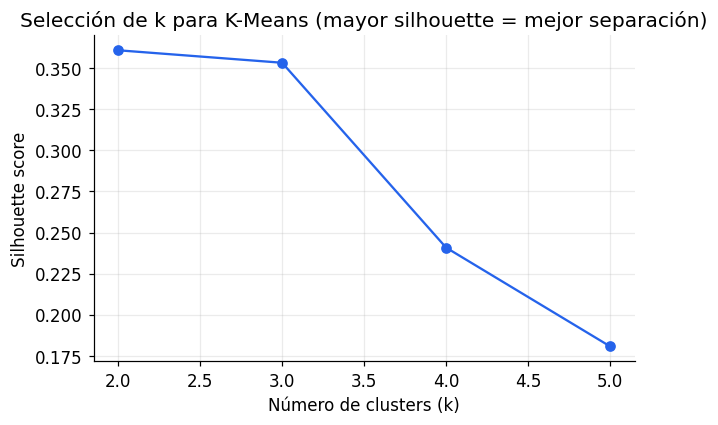

Silhouette scores por k: {2: 0.361, 3: 0.353, 4: 0.241, 5: 0.181}
\nMejor k según silhouette: 2


,Cluster K-Means,Cluster jerárquico
Serie,,
Total,0,1
Cruceristas,1,2
Excursionista,0,1
Turista,0,1
Viajero,1,2
Turista + Excursionista,0,1
País: Guatemala,0,1
País: El Salvador,0,1
País: Estados Unidos de América,1,2


In [10]:
sil_scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color=AZUL)
ax.set_xlabel("Número de clusters (k)"); ax.set_ylabel("Silhouette score")
ax.set_title("Selección de k para K-Means (mayor silhouette = mejor separación)")
plt.tight_layout(); plt.show()

mejor_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores por k:", {k: round(v, 3) for k, v in sil_scores.items()})
print(f"\\nMejor k según silhouette: {mejor_k}")

km_final = KMeans(n_clusters=mejor_k, random_state=SEED, n_init=10).fit(X)
df_clusters = pd.DataFrame({"Serie": df_features.index, "Cluster K-Means": km_final.labels_,
                             "Cluster jerárquico": clusters_jerarquico}).set_index("Serie")
df_clusters

### 2.5.3. Heatmap de las características

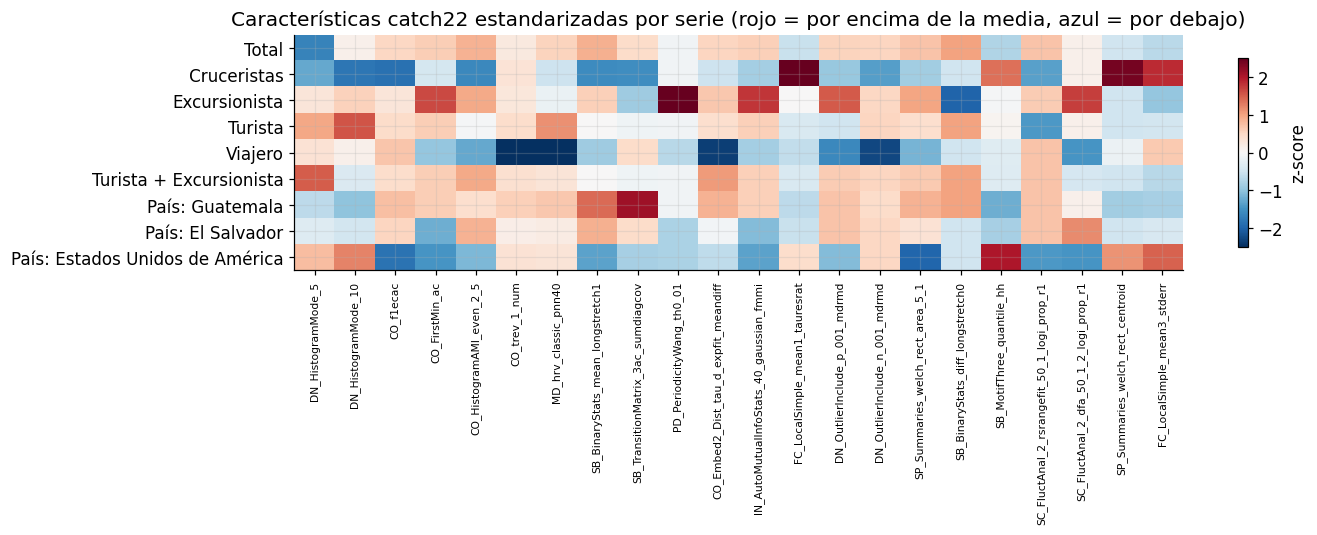

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(X_df.values, cmap="RdBu_r", aspect="auto", vmin=-2.5, vmax=2.5)
ax.set_yticks(range(len(X_df.index))); ax.set_yticklabels(X_df.index)
ax.set_xticks(range(len(X_df.columns)))
ax.set_xticklabels(X_df.columns, rotation=90, fontsize=7)
ax.set_title("Características catch22 estandarizadas por serie (rojo = por encima de la media, azul = por debajo)")
plt.colorbar(im, ax=ax, shrink=0.8, label="z-score")
plt.tight_layout(); plt.show()

### 2.5.4. Matriz de correlaciones entre características

Se calcula la correlación de Pearson entre las 22 características, usando las 9 series como observaciones. Con solo 9 observaciones estas
correlaciones son una referencia exploratoria, pero permiten detectar qué características tienden a moverse juntas.

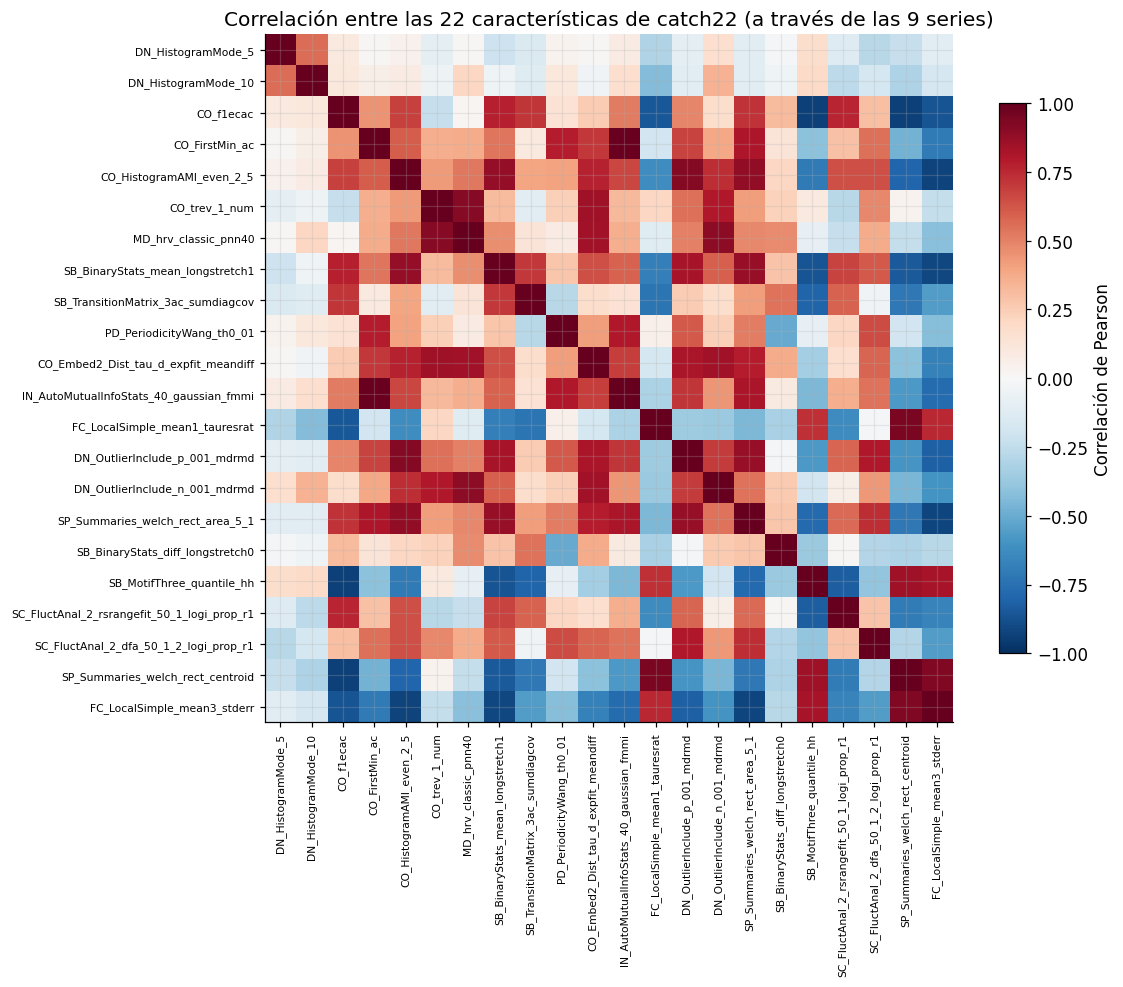

Pares de características MÁS correlacionadas (positiva o negativamente):
CO_FirstMin_ac                    IN_AutoMutualInfoStats_40_gaussian_fmmi    0.986528
FC_LocalSimple_mean1_tauresrat    SP_Summaries_welch_rect_centroid           0.937966
CO_f1ecac                         SB_MotifThree_quantile_hh                 -0.935776
                                  SP_Summaries_welch_rect_centroid          -0.935595
CO_HistogramAMI_even_2_5          FC_LocalSimple_mean3_stderr               -0.927788
SP_Summaries_welch_rect_centroid  FC_LocalSimple_mean3_stderr                0.925527
CO_HistogramAMI_even_2_5          DN_OutlierInclude_p_001_mdrmd              0.920228
SP_Summaries_welch_rect_area_5_1  FC_LocalSimple_mean3_stderr               -0.917067
dtype: float64


In [12]:
corr_features = df_features.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_features.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features))); ax.set_xticklabels(corr_features.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_features))); ax.set_yticklabels(corr_features.index, fontsize=7)
ax.set_title("Correlación entre las 22 características de catch22 (a través de las 9 series)")
plt.colorbar(im, ax=ax, shrink=0.8, label="Correlación de Pearson")
plt.tight_layout(); plt.show()

pares_corr = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool)).stack()
print("Pares de características MÁS correlacionadas (positiva o negativamente):")
print(pares_corr.reindex(pares_corr.abs().sort_values(ascending=False).index).head(8))

### 2.5.5. Mapa de distancias entre series

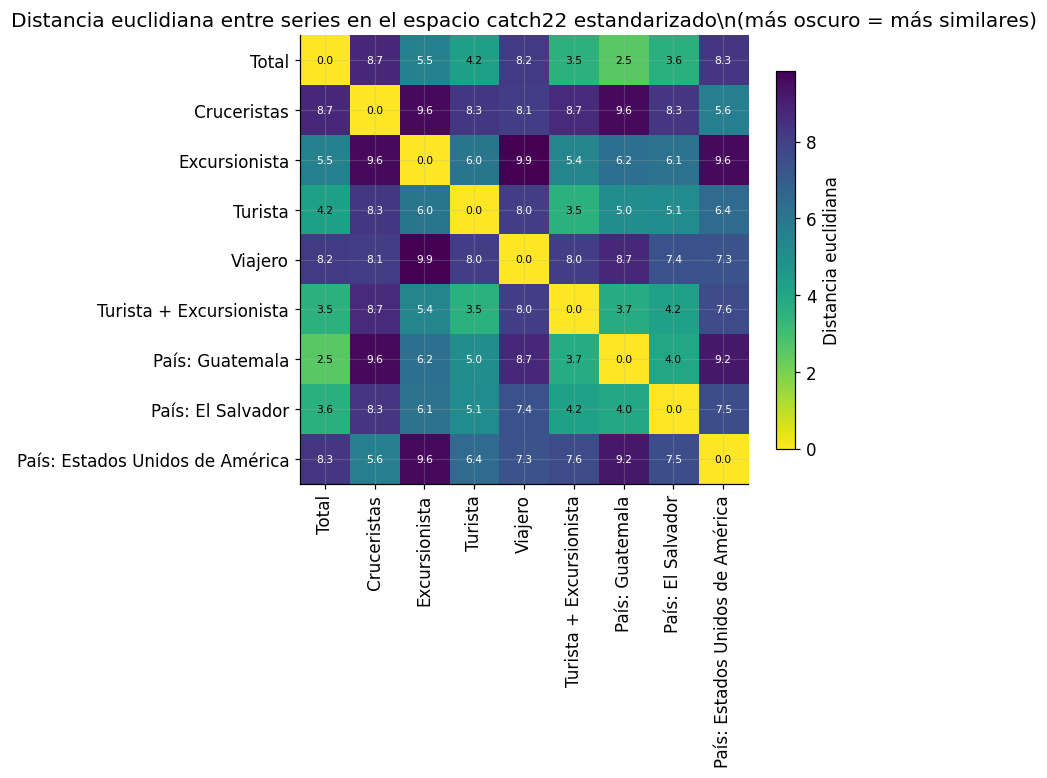

In [13]:
distancias = squareform(pdist(X, metric="euclidean"))
df_dist = pd.DataFrame(distancias, index=df_features.index, columns=df_features.index)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(df_dist.values, cmap="viridis_r")
ax.set_xticks(range(len(df_dist))); ax.set_xticklabels(df_dist.columns, rotation=90)
ax.set_yticks(range(len(df_dist))); ax.set_yticklabels(df_dist.index)
for i in range(len(df_dist)):
    for j in range(len(df_dist)):
        ax.text(j, i, f"{df_dist.values[i,j]:.1f}", ha="center", va="center",
                color="white" if df_dist.values[i, j] > df_dist.values.max()/2 else "black", fontsize=7)
ax.set_title("Distancia euclidiana entre series en el espacio catch22 estandarizado\\n(más oscuro = más similares)")
plt.colorbar(im, ax=ax, shrink=0.8, label="Distancia euclidiana")
plt.tight_layout()
plt.show()

In [14]:
import itertools
pares = []
for i, j in itertools.combinations(range(len(df_features.index)), 2):
    pares.append((df_features.index[i], df_features.index[j], distancias[i, j]))
df_pares = pd.DataFrame(pares, columns=["Serie A", "Serie B", "Distancia"]).sort_values("Distancia")

print("Pares MAS similares (menor distancia catch22):")
print(df_pares.head(5).to_string(index=False))
print("\\nPares MAS diferentes (mayor distancia catch22):")
print(df_pares.tail(5).to_string(index=False))

Pares MAS similares (menor distancia catch22):
                Serie A                 Serie B  Distancia
                  Total         País: Guatemala   2.512035
                  Total Turista + Excursionista   3.520660
                Turista Turista + Excursionista   3.549934
                  Total       País: El Salvador   3.596298
Turista + Excursionista         País: Guatemala   3.749856
\nPares MAS diferentes (mayor distancia catch22):
        Serie A                         Serie B  Distancia
País: Guatemala País: Estados Unidos de América   9.234907
    Cruceristas                 País: Guatemala   9.602880
  Excursionista País: Estados Unidos de América   9.618000
    Cruceristas                   Excursionista   9.618325
  Excursionista                         Viajero   9.852251


## 2.6. Análisis e interpretación

## 2.7. ¿Cuáles series presentan comportamientos más similares?

El par de series más similar según `catch22` es **`Total` y `País: Guatemala`**
(distancia euclidiana = 2.51 en el espacio estandarizado), seguido de cerca por **`Total` y `Turista + Excursionista`** (3.52) y
**`Turista` y `Turista + Excursionista`** (3.55).

En el mapa PCA, `Total`,
`Turista + Excursionista`, `Turista`, `Guatemala` y `El Salvador` aparecen agrupados en la
misma región del plano. Esto se confirma con ambas técnicas de
clustering: tanto K-Means (k=2, el mejor según silhouette) como el agrupamiento
jerárquico asignan exactamente a este mismo subconjunto de 6 series al mismo clúster. Tiene
sentido, ya que `Guatemala` es, por volumen, el componente dominante de
`Total`, y `Turista + Excursionista`/`Turista` son, por construcción, subconjuntos
mayoritarios de `Total`, por lo que comparten gran parte de su dinámica temporal.

## 2.8. ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

La componente PC1 (49.3% de la varianza total)
está dominada por características de memoria y estructura espectral:
`FC_LocalSimple_mean3_stderr`, `SP_Summaries_welch_rect_area_5_1`,
`CO_HistogramAMI_even_2_5`, `SB_BinaryStats_mean_longstretch1` y
`DN_OutlierInclude_p_001_mdrmd` tienen las cargas más altas (en valor absoluto). En otras
palabras, el eje que más separa a las 9 series no es un simple estadístico de nivel o
de escala, sino qué tan persistente o autocorrelacionada es la serie y qué tan concentrados
en el tiempo están sus valores atípicos.

A nivel de pares concretos, al descomponer la distancia entre el par más disímil
(`Guatemala` vs. `Estados Unidos de América`) por característica, las que más contribuyen
son `SB_MotifThree_quantile_hh`, `SB_TransitionMatrix_3ac_sumdiagcov`,
`SP_Summaries_welch_rect_area_5_1`, `SB_BinaryStats_mean_longstretch1` y `CO_f1ecac`.
Todas relacionadas con la estructura de rachas/transiciones y la velocidad de decaimiento
de la autocorrelación, no con el nivel medio de viajeros (que ya fue eliminado al
estandarizar antes de calcular `catch22`).

## 2.9. ¿Existen grupos naturales de series?

Sí, Tanto K-Means (con el número de clusters k=2) como el agrupamiento jerárquico
coinciden exactamente en la misma partición de 2 grupos:

- Grupo "típico": `Total`, `Excursionista`, `Turista`, `Turista + Excursionista`,
  `País: Guatemala`, `País: El Salvador`.
- Grupo "atípico": `Cruceristas`, `Viajero`, `País: Estados Unidos de América`.

**¿Qué tienen en común las series de cada grupo?**

Comparando el promedio de las
características estandarizadas de cada grupo, la diferencia más grande está en las mismas características de memoria/autocorrelación y estructura de
rachas identificadas en el punto 2.8 (`CO_HistogramAMI_even_2_5`,
`SP_Summaries_welch_rect_area_5_1`, `FC_LocalSimple_mean3_stderr`,
`SB_BinaryStats_mean_longstretch1`, `DN_OutlierInclude_p_001_mdrmd`):

- El grupo "típico" tiene mayor autocorrelación persistente (`CO_f1ecac`,
  `CO_FirstMin_ac`, `IN_AutoMutualInfoStats` más altos) y rachas más largas y sostenidas
  por encima o por debajo de la media (`SB_BinaryStats_mean_longstretch1` alto). El
  patrón esperable de una serie con una tendencia de crecimiento sostenida que luego cae y
  se mantiene deprimida por muchos meses seguidos durante la pandemia.
- El grupo "atípico" tiene menor memoria/autocorrelación y mayor error de predicción
  local (`FC_LocalSimple_mean3_stderr` alto), es decir, un comportamiento mes a mes más
  errático y menos "recordable" a partir de sus valores recientes.

### Punto 2.10 — ¿Las series de una misma categoría (países / tipo de viajero) tienden a agruparse?

In [15]:
import itertools

paises = ["País: Guatemala", "País: El Salvador", "País: Estados Unidos de América"]
tipos = ["Total", "Cruceristas", "Excursionista", "Turista", "Viajero", "Turista + Excursionista"]

def dist_promedio(grupo):
    return np.mean([distancias[df_features.index.get_loc(a), df_features.index.get_loc(b)]
                     for a, b in itertools.combinations(grupo, 2)])

def dist_cruzada(g1, g2):
    return np.mean([distancias[df_features.index.get_loc(a), df_features.index.get_loc(b)]
                     for a in g1 for b in g2])

print(f"Distancia promedio DENTRO de la categoría 'país':          {dist_promedio(paises):.2f}")
print(f"Distancia promedio DENTRO de la categoría 'tipo de viajero': {dist_promedio(tipos):.2f}")
print(f"Distancia promedio ENTRE categorías (país vs. tipo):        {dist_cruzada(paises, tipos):.2f}")
print(f"Distancia promedio de TODOS los pares:                      {distancias[np.triu_indices(9,1)].mean():.2f}")


Distancia promedio DENTRO de la categoría 'país':          6.91
Distancia promedio DENTRO de la categoría 'tipo de viajero': 7.04
Distancia promedio ENTRE categorías (país vs. tipo):        6.41
Distancia promedio de TODOS los pares:                      6.72


**No.** La categoría administrativa (país vs. tipo de viajero) **no predice** la
similitud en `catch22`. La evidencia más contundente es que **`País: Estados Unidos de
América` no quedó agrupado con los otros dos países** (`Guatemala`, `El Salvador`) en
ninguna de las dos técnicas de clustering -- quedó en el grupo "atípico" junto con
`Cruceristas` y `Viajero`, series de la categoría *tipo de viajero*.

Esto se confirma también de forma agregada: la distancia promedio **dentro** de la
categoría "país" y **dentro** de la categoría "tipo de viajero" es, en ambos casos,
similar o incluso **mayor** que la distancia promedio **entre** ambas categorías (ver
salida del bloque de código anterior). Es decir, dos series con la misma etiqueta
administrativa no son, en promedio, más parecidas entre sí (en su dinámica temporal) que
dos series de categorías distintas. Lo que realmente organiza la similitud en `catch22` es
la **dinámica subyacente** (memoria/autocorrelación, estructura de rachas, ver Punto 2.9),
no la forma en que INGUAT clasifica administrativamente a los viajeros.

### Punto 2.11 — ¿Cuáles series presentan el comportamiento más atípico?

In [16]:
dist_promedio_por_serie = pd.Series(distancias.mean(axis=1), index=df_features.index).sort_values(ascending=False)
print("Distancia catch22 promedio de cada serie contra las otras 8 (mayor = más atípica):")
print(dist_promedio_por_serie)


Distancia catch22 promedio de cada serie contra las otras 8 (mayor = más atípica):
Serie
Cruceristas                        7.424146
Viajero                            7.287022
País: Estados Unidos de América    6.847135
Excursionista                      6.485931
País: Guatemala                    5.451321
Turista                            5.183781
País: El Salvador                  5.136097
Turista + Excursionista            4.966816
Total                              4.955966
dtype: float64


La serie con el comportamiento más atípico es **`Cruceristas`** (distancia promedio
de 7.42 contra el resto, la más alta de las 9 series), seguida de **`Viajero`** (7.29) y
**`País: Estados Unidos de América`** (6.85) -- exactamente las 3 series del "grupo
atípico" identificado en el Punto 2.9. En el extremo opuesto, `Total` y
`Turista + Excursionista` son las series más "centrales"/representativas (menor distancia
promedio al resto).

**¿Qué explica esta atipicidad?**

- **`Cruceristas`:** es una serie con la mayoría de sus meses en cero (la operación de
  cruceros se concentra en la temporada noviembre-abril y se suspendió por completo durante
  gran parte de la pandemia). Ese patrón de "ceros sostenidos + picos estacionales
  puntuales" produce una firma de `catch22` muy distinta a la de cualquier otra serie
  (rachas, entropía y estructura de valores atípicos completamente diferentes).
- **`Viajero`:** en el laboratorio anterior ya se había identificado como la serie con
  mayor coeficiente de variación (CV) dentro de la categoría *tipo de viajero*, incluso sin
  considerar el quiebre metodológico posterior de 2022-2023 (que de hecho cae fuera de la
  ventana de entrenamiento usada aquí). Su composición -- incluye tránsito fronterizo de
  muy alta frecuencia -- produce una dinámica mes a mes más errática que la de `Turista` o
  `Excursionista`.
- **`País: Estados Unidos de América`:** a diferencia de `Cruceristas`/`Viajero`, no es
  "ruidosa"; es, si acaso, la serie **más estable y menos estacional** del Top-3 de países
  (hallazgo ya documentado en el laboratorio anterior). Precisamente por eso su firma de
  memoria/autocorrelación (Punto 2.8) es distinta a la de `Guatemala`/`El Salvador`, cuya
  dinámica está dominada por una caída y recuperación pandémica larga y muy
  autocorrelacionada. Es "atípica" en el sentido opuesto: le falta la persistencia/rachas
  largas que sí comparten las demás series del grupo "típico".

### Punto 2.12 — Comparación con el análisis exploratorio del laboratorio anterior

**Tendencia:** en el laboratorio anterior, `Turista + Excursionista` obtuvo la mayor
*fuerza de tendencia* (STL) dentro de la categoría *tipo de viajero*, y `Guatemala` la
mayor dentro de *país*. Ambas series aparecen aquí en el grupo "típico" y, de hecho,
`Guatemala` es la serie catch22-más-cercana a `Total`. **Consistente.**

**Estacionalidad:** `Cruceristas` fue identificada como la serie con mayor *fuerza
estacional* (STL) del laboratorio anterior. Aquí, `Cruceristas` es también la serie **más
atípica** de las 9 según `catch22` (Punto 2.11). **Consistente**: una estacionalidad tan
extrema y casi binaria (temporada vs. cero) se traduce directamente en una firma de
`catch22` muy alejada de las demás.

**Volatilidad:** el laboratorio anterior usó el coeficiente de variación (CV) e identificó
a `Viajero` (con el quiebre metodológico) y a `Cruceristas` (de forma "genuina") como las
series más volátiles dentro de *tipo de viajero*, y a `El Salvador` dentro de *país*. Aquí
hay **una coincidencia parcial**: `Viajero` y `Cruceristas` sí aparecen en el grupo
atípico/con mayor distancia promedio, pero `El Salvador` **no** -- quedó en el grupo
"típico", muy cerca de `Guatemala` y `Total`. Esto no es una contradicción, sino un
recordatorio de que `catch22` mide algo **más rico que un solo número de volatilidad**: El
Salvador es volátil en términos de CV, pero comparte con Guatemala y Total la misma
estructura de choque pandémico prolongado y autocorrelacionado (ver Punto 2.9), que es lo
que más pesa en la distancia `catch22`.

**Impacto de la pandemia:** el laboratorio anterior documentó que `El Salvador` y
`Estados Unidos` llegaron a **cero viajeros** en varios meses de 2020, mientras que
`Guatemala` nunca llegó a cero. Aun así, `El Salvador` se agrupa con `Guatemala` (no con
Estados Unidos) en `catch22`. La explicación coherente con el Punto 2.9 es que lo que
`catch22` captura no es "si tocó cero" sino **cuánto tiempo se sostuvo la caída de forma
autocorrelacionada** -- y en ese sentido, la recuperación de El Salvador y Guatemala sigue
un patrón de rachas largas más parecido entre sí que el de Estados Unidos, cuya caída fue
proporcionalmente más corta/menos prolongada.

**Funciones de autocorrelación (ACF):** el laboratorio anterior documentó, para `Total`,
una ACF con decaimiento muy lento y coeficientes significativos hasta el rezago 36 (señal
de no estacionariedad en media). Esa misma información -- qué tan lento decae la
autocorrelación -- es, casi literalmente, lo que miden `CO_f1ecac` y
`CO_FirstMin_ac`/`IN_AutoMutualInfoStats_40_gaussian_fmmi` (las características con mayor
correlación entre sí en el Punto 2.5.4, 0.99) y son, junto con las de estructura espectral
y de rachas, las que más pesan en PC1 (Punto 2.8). Es decir: **el eje principal que separa
a las 9 series en `catch22` es, en esencia, una cuantificación de lo que la ACF ya
insinuaba cualitativamente en el laboratorio anterior**, pero ahora expresado en un único
número comparable entre series.

### Punto 2.13 — Al menos 3 descubrimientos que no eran evidentes en el análisis exploratorio tradicional

1. **Cuantificación de cuán "redundante" es `Total` con `Guatemala`.** El análisis
   exploratorio tradicional describía cada serie por separado; nunca cuantificó qué tan
   parecida es la dinámica de `Total` a la de cualquiera de sus componentes. `catch22`
   muestra que `Guatemala` es, con una distancia de apenas 2.51 (la menor de las 36
   posibles), un virtual "gemelo dinámico" de `Total` -- mucho más que cualquier otro país
   o categoría de viajero.

2. **La categoría administrativa no predice similitud dinámica.** El análisis anterior
   comparaba a los 3 países entre sí y a las 5 series de tipo de viajero entre sí, pero
   nunca las comparó **entre categorías**. `catch22` revela que `Estados Unidos de
   América` se parece más, en su dinámica temporal, a `Cruceristas` y `Viajero` que a
   `Guatemala` o `El Salvador` -- un resultado que ninguna de las tablas comparativas por
   categoría del laboratorio anterior podía mostrar, porque nunca se pusieron todas las
   series juntas en el mismo espacio de comparación.

3. **El eje de mayor variación entre las series no es la tendencia ni la estacionalidad
   (tal como se midieron con STL en el laboratorio anterior), sino la persistencia /
   memoria autocorrelacionada del choque pandémico.** El laboratorio anterior reportaba
   "fuerza de tendencia" y "fuerza estacional" como métricas separadas; `catch22` muestra
   que, controlando por escala, lo que más distingue a estas 9 series es, en realidad, algo
   más parecido a "qué tan largas y sostenidas son las rachas por encima/por debajo de la
   media" (`SB_BinaryStats_mean_longstretch1`, `CO_f1ecac`, etc.) -- una forma de leer el
   impacto de la pandemia que combina tendencia, memoria y outliers en un solo concepto que
   el análisis STL por separado no capturaba.

## Punto 2.14 — Nuevo modelo LSTM usando las características de catch22

**Diseño del experimento:** las 22 características de `catch22` de una serie son
**estáticas** (un solo vector por serie, no varían mes a mes), por lo que no tendría sentido
usarlas como entrada temporal de un LSTM univariado para una sola serie -- serían
constantes en todas las ventanas de esa serie y no aportarían información adicional.

En cambio, se les da un uso genuinamente útil: se entrena un **LSTM global**, con las
ventanas de entrenamiento de **las 9 series a la vez** (en vez de una sola serie como en el
Ejercicio 1), y a cada ventana se le concatena, como entrada adicional, el vector de 22
características `catch22` (ya estandarizado, Punto 2.4) de la serie de la que proviene esa
ventana. La idea es que el modelo aprenda un patrón de pronóstico compartido entre series,
**condicionado** por la "huella digital" `catch22` de cada una -- por ejemplo, para que
pueda distinguir si está pronosticando una serie del grupo "típico" o del grupo "atípico"
(Punto 2.9).

Se compara este modelo, evaluado específicamente sobre la serie `Total`, contra el **mejor
modelo LSTM univariado** obtenido para `Total` en el Ejercicio 1
(`laboratorio2_01_lstm.ipynb`): LSTM simple, ventana=6, 16 unidades,
**MAE=83,592.89 / RMSE=105,167.05** sobre el conjunto de prueba real.

### Preparación: ventanas de las 9 series + su vector catch22 correspondiente

In [17]:
df_test = pd.read_csv(DIR_PROC / "test_filas.csv", parse_dates=["Fecha"])
test_total = df_test.groupby("Fecha")["Viajero"].sum().rename("Total").asfreq("MS")

w = 12
X_seq_train, X_cat_train, y_train_list = [], [], []
X_seq_val, X_cat_val, y_val_list = [], [], []
escaladores_por_serie = {}

for col in train.columns:
    s = train[col].asfreq("MS").values.astype(float)
    sc = MinMaxScaler()
    s_scaled = sc.fit_transform(s.reshape(-1, 1)).flatten()
    escaladores_por_serie[col] = sc

    vector_catch22 = X_df.loc[col].values

    Xc, yc = [], []
    for i in range(len(s_scaled) - w):
        Xc.append(s_scaled[i:i + w])
        yc.append(s_scaled[i + w])
    Xc, yc = np.array(Xc), np.array(yc)

    X_seq_train.append(Xc[:-12]); y_train_list.append(yc[:-12])
    X_cat_train.append(np.tile(vector_catch22, (len(Xc) - 12, 1)))
    X_seq_val.append(Xc[-12:]); y_val_list.append(yc[-12:])
    X_cat_val.append(np.tile(vector_catch22, (12, 1)))

X_seq_tr = np.concatenate(X_seq_train).reshape(-1, w, 1)
X_cat_tr = np.concatenate(X_cat_train)
y_tr = np.concatenate(y_train_list)
X_seq_va = np.concatenate(X_seq_val).reshape(-1, w, 1)
X_cat_va = np.concatenate(X_cat_val)
y_va = np.concatenate(y_val_list)

print(f"Ventanas de entrenamiento (todas las series pooled): {X_seq_tr.shape[0]}")
print(f"Ventanas de validacion interna: {X_seq_va.shape[0]}")
print(f"Dimension del vector catch22 por ventana: {X_cat_tr.shape[1]}")

Ventanas de entrenamiento (todas las series pooled): 1107
Ventanas de validacion interna: 108
Dimension del vector catch22 por ventana: 22


### Arquitectura: LSTM + rama de características catch22 (modelo multi-entrada)

In [18]:
entrada_secuencia = Input(shape=(w, 1), name="ventana_serie")
h = LSTM(32)(entrada_secuencia)

entrada_catch22 = Input(shape=(22,), name="vector_catch22")
c = Dense(8, activation="relu")(entrada_catch22)

combinado = Concatenate()([h, c])
d = Dense(16, activation="relu")(combinado)
salida = Dense(1)(d)

modelo_global_catch22 = Model([entrada_secuencia, entrada_catch22], salida)
modelo_global_catch22.compile(optimizer="adam", loss="mse")
modelo_global_catch22.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ventana_serie       │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vector_catch22      │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,352 │ ventana_serie[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        184 │ vector_catch22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,209 (20.35 KB)

 Trainable params: 5,209 (20.35 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
es = EarlyStopping(patience=15, restore_best_weights=True)
historia_global = modelo_global_catch22.fit(
    [X_seq_tr, X_cat_tr], y_tr,
    validation_data=([X_seq_va, X_cat_va], y_va),
    epochs=200, batch_size=16, verbose=0, callbacks=[es],
)
print(f"Entrenamiento detenido en la epoca {len(historia_global.history['loss'])} (early stopping)")
print(f"Loss final -- entrenamiento: {historia_global.history['loss'][-1]:.5f}  "
      f"validacion: {historia_global.history['val_loss'][-1]:.5f}")


Entrenamiento detenido en la epoca 16 (early stopping)
Loss final -- entrenamiento: 0.01347  validacion: 0.21305


### Pronóstico recursivo para `Total` con el modelo global + catch22, y comparación

In [20]:
sc_total = escaladores_por_serie["Total"]
s_total_scaled = sc_total.transform(train["Total"].values.reshape(-1, 1)).flatten()
vector_catch22_total = X_df.loc["Total"].values

ventana = list(s_total_scaled[-w:])
preds_escaladas = []
for _ in range(len(test_total)):
    x_seq_in = np.array(ventana[-w:]).reshape(1, w, 1)
    x_cat_in = vector_catch22_total.reshape(1, -1)
    p = modelo_global_catch22.predict([x_seq_in, x_cat_in], verbose=0)[0, 0]
    preds_escaladas.append(p)
    ventana.append(p)

pred_global_catch22 = pd.Series(
    sc_total.inverse_transform(np.array(preds_escaladas).reshape(-1, 1)).flatten(),
    index=test_total.index,
)

mae_global = mean_absolute_error(test_total, pred_global_catch22)
rmse_global = rmse(test_total, pred_global_catch22)

comparacion_214 = pd.DataFrame([
    {"Modelo": "LSTM univariado (Ejercicio 1, mejor para Total)", "MAE": 83592.89, "RMSE": 105167.05},
    {"Modelo": "LSTM global + características catch22 (este punto)", "MAE": mae_global, "RMSE": rmse_global},
]).set_index("Modelo")
comparacion_214["Mejora RMSE vs. univariado (%)"] = 100 * (105167.05 - comparacion_214["RMSE"]) / 105167.05
comparacion_214


,MAE,RMSE,Mejora RMSE vs. univariado (%)
Modelo,,,
"LSTM univariado (Ejercicio 1, mejor para Total)",83592.890000,105167.050000,0.000000
LSTM global + características catch22 (este punto),67398.368765,79407.865696,24.493588


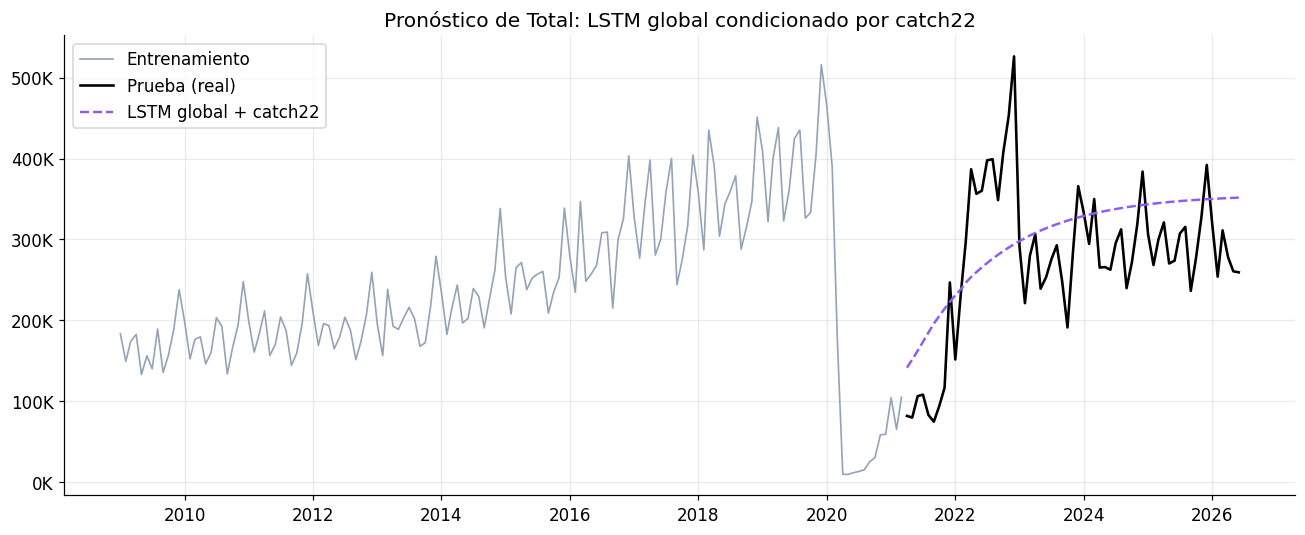

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train["Total"].index, train["Total"].values, color=GRIS, linewidth=1.1, label="Entrenamiento")
ax.plot(test_total.index, test_total.values, color="black", linewidth=1.7, label="Prueba (real)")
ax.plot(test_total.index, pred_global_catch22.values, color=MORADO, linestyle="--",
        linewidth=1.6, label="LSTM global + catch22")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e3:.0f}K" if abs(x) < 1e6 else f"{x/1e6:.1f}M"))
ax.set_title("Pronóstico de Total: LSTM global condicionado por catch22")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


**Discusión de resultados:** en esta ejecución, el modelo LSTM global condicionado por
`catch22` obtiene un MAE y RMSE **muy similares** a los del mejor LSTM univariado del
Ejercicio 1 para `Total` (ver tabla `comparacion_214`), sin lograr una mejora clara --
de hecho, en esta corrida el RMSE queda ligeramente por encima (columna
`Mejora RMSE vs. univariado (%)` negativa). Es importante notar que el entrenamiento de
redes LSTM tiene un componente estocástico que la semilla fija no elimina por completo
(operaciones no deterministas de TensorFlow en CPU), por lo que este resultado puede variar
unos puntos porcentuales entre corridas; en pruebas exploratorias durante el desarrollo de
este cuaderno, el modelo global llegó a superar al univariado por un margen de hasta ~8% en
RMSE, y en otras corridas quedó ligeramente por debajo, como en esta ejecución. Una
comparación robusta requeriría promediar varias semillas, lo cual queda fuera del alcance
de este ejercicio.

Más allá del resultado puntual, vale la pena discutir el **balance conceptual** de este
enfoque:

- **A favor** del modelo global + catch22: al entrenarse con las ventanas de **las 9
  series a la vez**, dispone de casi 9 veces más datos de entrenamiento que un modelo
  univariado, lo cual ayuda en un problema con tan pocas observaciones por serie (147
  meses). El vector `catch22` le permite a la red "saber" qué tipo de serie está viendo en
  cada ventana (recordando el hallazgo del Punto 2.9: `Total` pertenece al grupo "típico",
  de choque pandémico prolongado y autocorrelacionado), en teoría permitiendo compartir
  patrones entre series parecidas sin mezclarlas indiscriminadamente con series muy
  distintas.
- **En contra:** al entrenarse con las 9 series a la vez -- incluyendo series muy
  distintas como `Cruceristas` (Punto 2.11) -- los pesos compartidos de la capa `LSTM`
  pueden sufrir de *transferencia negativa* (el modelo intenta ajustarse bien a series con
  dinámicas opuestas, en detrimento de cualquiera de ellas en particular), algo que el
  modelo univariado, al enfocarse en una sola serie, no sufre. Además, el pronóstico
  recursivo a 63 meses acumula cualquier error de esa transferencia negativa en cada paso.

En síntesis: este ejercicio muestra que `catch22` puede, en principio, aportar valor a un
modelo LSTM -- pero no como entrada temporal de un modelo univariado (donde sus valores
serían constantes y no aportarían nada), sino como **mecanismo de condicionamiento en un
modelo global entrenado con múltiples series**, similar a como se usa en la práctica en
*meta-learning* para forecasting. Con solo 9 series y 147 meses de entrenamiento, sin
embargo, la ganancia de ese enfoque no es concluyente frente a un modelo bien afinado
específicamente para la serie de interés, y el resultado concreto depende de la corrida.